# **Data Migration**

## **Libraries and Config**


In [ ]:
import google.oauth2.service_account as service_account
import pandas_gbq
from google.cloud import bigquery

In [ ]:
project_id = 'data-mining-project-438918'
dataset_id = 'deutsche_bahn_data'

credentials = service_account.Credentials.from_service_account_file('/content/credentials.json')

client = bigquery.Client(credentials=credentials, project=project_id)

## **Migration to the cloud**

### **Data Preparation**

In [ ]:
df_clean['arrival_plan_time'] = df_clean['arrival_plan_time'].astype(str)
df_clean['departure_plan_time'] = df_clean['departure_plan_time'].astype(str)

df_clean['arrival_plan_date'] = pd.to_datetime(df_clean['arrival_plan_date']).dt.strftime('%Y-%m-%d')
df_clean['departure_plan_date'] = pd.to_datetime(df_clean['departure_plan_date']).dt.strftime('%Y-%m-%d')

The following steps must be executed in order to match data types with bigquery types thus solving possible schema errors like:



*   ArrowTypeError: Error converting Pandas column with name: "arrival_plan_time" and datatype: "object" to an appropriate pyarrow datatype: Array, ListArray, or StructArray
*   ArrowTypeError: Error converting Pandas column with name: "arrival_plan_date" and datatype: "object" to an appropriate pyarrow datatype: Array, ListArray, or StructArray



In [ ]:
table_name = f'deutsche_bahn_data'

table_schema = None

df_ = df_clean

# Guardar en BigQuery
pandas_gbq.to_gbq(df_, f'{project_id}.{dataset_id}.{table_name}', project_id=project_id, if_exists='replace', credentials=credentials)

100%|██████████| 1/1 [00:00<00:00, 197.66it/s]


# **Model**

## **Retrieve data from bigquery**

In [ ]:
dataset_ref = bigquery.DatasetReference(project_id, dataset_id)
table_ref = dataset_ref.table("deutsche_bahn_data")
table = client.get_table(table_ref)

In [ ]:
df = client.list_rows(table).to_dataframe()

In [ ]:
df

,line,path,category,station,state,city,long,lat,arrival_plan,departure_plan,...,departure_change,arrival_delay_m,departure_delay_m,info,arrival_delay_check,departure_delay_check,arrival_plan_time,arrival_plan_date,departure_plan_time,departure_plan_date
0,1,Norddeich|Norden|Marienhafe|Emden Hbf|Leer(Ost...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 06:44:00+00:00,2024-07-08 06:45:00+00:00,...,2024-07-08 07:31:00+00:00,46,46,Information,delay,delay,06:44:00,2024-07-08,06:45:00,2024-07-08
1,1,Hannover Hbf|Wunstorf|Neustadt am Rübenberge|N...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 07:11:00+00:00,2024-07-08 07:12:00+00:00,...,2024-07-08 07:13:00+00:00,0,1,Information,on_time,on_time,07:11:00,2024-07-08,07:12:00,2024-07-08
2,1,Norddeich|Norden|Marienhafe|Emden Hbf|Leer(Ost...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 08:44:00+00:00,2024-07-08 08:45:00+00:00,...,2024-07-08 09:00:00+00:00,14,15,Information,delay,delay,08:44:00,2024-07-08,08:45:00,2024-07-08
3,1,Hannover Hbf|Wunstorf|Neustadt am Rübenberge|N...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 09:11:00+00:00,2024-07-08 09:12:00+00:00,...,2024-07-08 09:12:00+00:00,0,0,Information,on_time,on_time,09:11:00,2024-07-08,09:12:00,2024-07-08
4,1,Norddeich Mole|Norddeich|Norden|Marienhafe|Emd...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 10:44:00+00:00,2024-07-08 10:45:00+00:00,...,2024-07-08 10:46:00+00:00,1,1,Information,on_time,on_time,10:44:00,2024-07-08,10:45:00,2024-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514406,RS30,Bad Zwischenahn|Oldenburg-Wechloy,2,Oldenburg (Oldb) Hbf,Niedersachsen,Oldenburg (Oldb),8.222713,53.144323,2024-07-11 19:57:00+00:00,2024-07-11 20:06:00+00:00,...,2024-07-11 20:06:00+00:00,0,0,Information,on_time,on_time,19:57:00,2024-07-11,20:06:00,2024-07-11
514407,RS30,Bad Zwischenahn|Oldenburg-Wechloy,2,Oldenburg (Oldb) Hbf,Niedersachsen,Oldenburg (Oldb),8.222713,53.144323,2024-07-11 20:57:00+00:00,2024-07-11 21:05:00+00:00,...,2024-07-11 21:05:00+00:00,0,0,Information,on_time,on_time,20:57:00,2024-07-11,21:05:00,2024-07-11
514408,RS30,Bremen Hbf|Delmenhorst|Hude,2,Oldenburg (Oldb) Hbf,Niedersachsen,Oldenburg (Oldb),8.222713,53.144323,2024-07-11 20:53:00+00:00,2024-07-11 20:58:00+00:00,...,2024-07-11 20:58:00+00:00,0,0,Information,on_time,on_time,20:53:00,2024-07-11,20:58:00,2024-07-11
514409,RS30,Bad Zwischenahn|Oldenburg-Wechloy,2,Oldenburg (Oldb) Hbf,Niedersachsen,Oldenburg (Oldb),8.222713,53.144323,2024-07-11 19:57:00+00:00,2024-07-11 20:06:00+00:00,...,2024-07-11 20:07:00+00:00,1,1,Information,on_time,on_time,19:57:00,2024-07-11,20:06:00,2024-07-11


## **Temporal analysis**

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
import math
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [ ]:
date_format = "%Y-%m-%d %H:%M:%S"
df["arrival_plan"] = pd.to_datetime(df["arrival_plan"], format=date_format)
df["departure_plan"] = pd.to_datetime(df["departure_plan"], format=date_format)
df["arrival_change"] = pd.to_datetime(df["arrival_change"], format=date_format)
df["departure_change"] = pd.to_datetime(df["departure_change"], format=date_format)
df["departure_plan_hour"] = df["departure_plan"].dt.hour
df["departure_plan_date"] = df["departure_plan"].dt.date

df = df.dropna(subset=["departure_plan"])
df.loc[:, "departure_plan_hour"] = df["departure_plan"].dt.hour
df.loc[:, "departure_plan_datetime"] = (
    df["departure_plan_date"].astype(str) + ' ' +
    df["departure_plan_hour"].astype(str) + ':00:00'
)
df.loc[:, "departure_plan_datetime"] = pd.to_datetime(df["departure_plan_datetime"], format=date_format)

df.head()

,line,path,category,station,state,city,long,lat,arrival_plan,departure_plan,...,departure_delay_m,info,arrival_delay_check,departure_delay_check,arrival_plan_time,arrival_plan_date,departure_plan_time,departure_plan_date,departure_plan_hour,departure_plan_datetime
0,1,Norddeich|Norden|Marienhafe|Emden Hbf|Leer(Ost...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 06:44:00+00:00,2024-07-08 06:45:00+00:00,...,46,Information,delay,delay,06:44:00,2024-07-08,06:45:00,2024-07-08,6,2024-07-08 06:00:00
1,1,Hannover Hbf|Wunstorf|Neustadt am Rübenberge|N...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 07:11:00+00:00,2024-07-08 07:12:00+00:00,...,1,Information,on_time,on_time,07:11:00,2024-07-08,07:12:00,2024-07-08,7,2024-07-08 07:00:00
2,1,Norddeich|Norden|Marienhafe|Emden Hbf|Leer(Ost...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 08:44:00+00:00,2024-07-08 08:45:00+00:00,...,15,Information,delay,delay,08:44:00,2024-07-08,08:45:00,2024-07-08,8,2024-07-08 08:00:00
3,1,Hannover Hbf|Wunstorf|Neustadt am Rübenberge|N...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 09:11:00+00:00,2024-07-08 09:12:00+00:00,...,0,Information,on_time,on_time,09:11:00,2024-07-08,09:12:00,2024-07-08,9,2024-07-08 09:00:00
4,1,Norddeich Mole|Norddeich|Norden|Marienhafe|Emd...,4,Hude,Niedersachsen,Hude,8.460956,53.109429,2024-07-08 10:44:00+00:00,2024-07-08 10:45:00+00:00,...,1,Information,on_time,on_time,10:44:00,2024-07-08,10:45:00,2024-07-08,10,2024-07-08 10:00:00


In [ ]:
scaler = MinMaxScaler()

In [ ]:
tsa = df[["departure_plan_datetime","departure_delay_m","departure_plan_hour"]].groupby("departure_plan_datetime", as_index=False).mean()
tsa = tsa.set_index('departure_plan_datetime').asfreq('h', fill_value=tsa.departure_delay_m.mean())
tsa.sort_index(inplace=True)

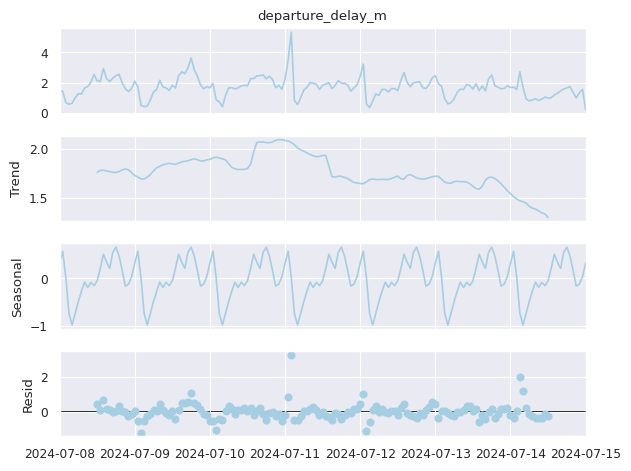

In [ ]:
decomposition = seasonal_decompose(tsa['departure_delay_m'], model='additive', period=24)
decomposition.plot()
plt.show()

In [ ]:
tsa["departure_delay_m"] = scaler.fit_transform(tsa[["departure_delay_m"]])
tsa.head()

,departure_delay_m,departure_plan_hour
departure_plan_datetime,,
2024-07-08 00:00:00,0.253413,0.0
2024-07-08 01:00:00,0.237755,1.0
2024-07-08 02:00:00,0.093632,2.0
2024-07-08 03:00:00,0.072690,3.0
2024-07-08 04:00:00,0.085685,4.0


In [ ]:
statelist = df.state.unique()
frames = {}

for state in statelist:
    frames[state] = df[df["state"] == state]
    frames[state] = frames[state][["departure_plan_datetime","departure_delay_m","departure_plan_hour"]].groupby("departure_plan_datetime", as_index=False).mean()

    # Ensure 'departure_delay_m' is numeric before calculating zscore
    frames[state]['departure_delay_m'] = pd.to_numeric(frames[state]['departure_delay_m'], errors='coerce')  # Convert to numeric, replacing non-numeric with NaN
    frames[state]['zscore'] = zscore(frames[state]['departure_delay_m'].astype(np.float64))  # Explicitly cast to float64

    # Identify outliers with Z-score threshold of 3
    outliers = frames[state][np.abs(frames[state]['zscore']) > 3]

    # Replace outliers with the median of the surrounding values
    for index in outliers.index:

        frames[state].at[index, 'departure_delay_m'] = frames[state]['departure_delay_m'].median() #only flattening the most excessive spikes for some states

    # Drop the zscore column as it's no longer needed
    frames[state] = frames[state].drop(columns=['zscore'])
    frames[state]['departure_delay_m'] = frames[state]['departure_delay_m'].rolling(window=3).mean()
    frames[state] = frames[state].set_index('departure_plan_datetime').asfreq('h', fill_value=frames[state].departure_delay_m.mean())
    frames[state]["departure_delay_m"] = scaler.fit_transform(frames[state][["departure_delay_m"]])

In [ ]:
result = adfuller(tsa['departure_delay_m'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

if result[1] < 0.05:
    print("Series is stationary. No differencing needed.")

ADF Statistic: -6.183985132395739
p-value: 6.354657425646128e-08
Critical Values: {'1%': -3.470126426071447, '5%': -2.8790075987120027, '10%': -2.5760826967621644}
Series is stationary. No differencing needed.


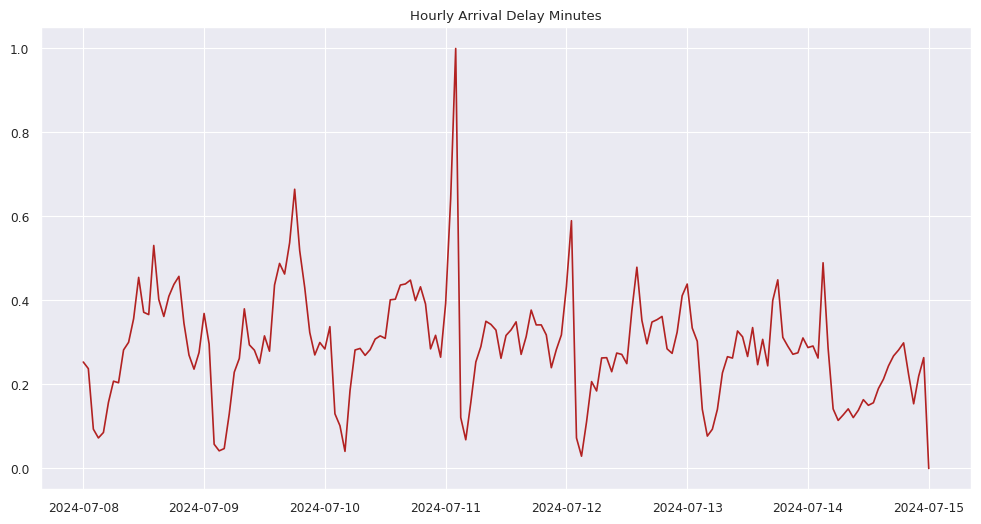

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(tsa['departure_delay_m'], color='firebrick')
plt.title('Hourly Arrival Delay Minutes')
plt.show()

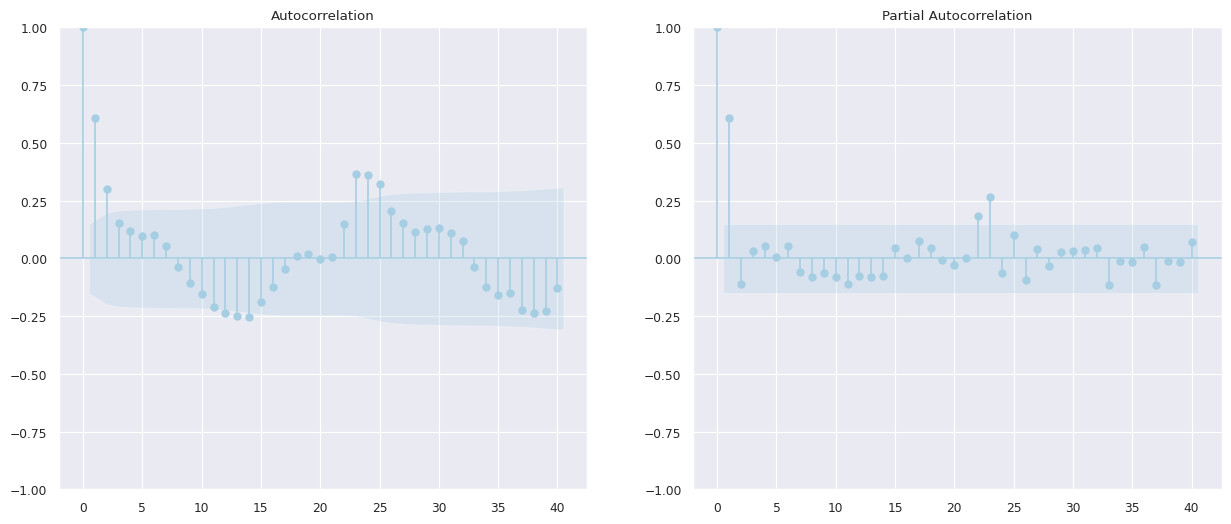

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(tsa['departure_delay_m'], lags=40, ax=axes[0])
plot_pacf(tsa['departure_delay_m'], lags=40, ax=axes[1])
plt.show()

In [ ]:
trainpart = 0.85

In [ ]:
i_split = int(trainpart * len(tsa))
tsa_train, tsa_test = tsa.iloc[:i_split,:], tsa.iloc[i_split:,:]

In [ ]:
len(tsa_test) # periods long

26

In [ ]:
p_values = range(1, 4)  # Autoregressive order
d_values = [0]          # Differencing order
q_values = range(1, 4)  # Moving average order
P_values = range(1, 4)  # Seasonal autoregressive order
D_values = range(0, 1)  # Seasonal differencing order
Q_values = range(1, 4)  # Seasonal moving average order
m_values = [24]         # Seasonal period

# Create all possible combinations of SARIMA parameters
param_combinations = list(itertools.product(p_values,
                                            d_values,
                                            q_values,
                                            P_values,
                                            D_values,
                                            Q_values,
                                            m_values))

# Initialize AIC with a large value
best_aic = float("inf")
best_params = None

In [ ]:
for params in param_combinations:
    order = params[:3]
    seasonal_order = params[3:]

    try:
        model = SARIMAX(tsa_train["departure_delay_m"],
                               order=order,
                               seasonal_order=seasonal_order)
        result = model.fit(disp=False, maxiter=100)
        aic = result.aic

        # Ensure the convergence of the model
        if not math.isinf(result.zvalues.mean()):
            print(order, seasonal_order, aic)

            if aic < best_aic:
                best_aic = aic
                best_params = params

        else:
            print(order, seasonal_order, 'not converged')

    except:
        continue

# Print the best parameters and AIC
print("Best Parameters:", best_params)
print("Best AIC:", best_aic)

(1, 0, 1) (1, 0, 1, 24) -212.9294806734192


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


(1, 0, 1) (1, 0, 2, 24) -211.98565750861906


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


(1, 0, 1) (1, 0, 3, 24) -210.87142429750878
(1, 0, 1) (2, 0, 1, 24) -211.89661782940755


...

(3, 0, 3) (2, 0, 3, 24) -220.14032974126422
(3, 0, 3) (3, 0, 1, 24) -222.87409087269356


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


(3, 0, 3) (3, 0, 2, 24) -220.3490250186934


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(3, 0, 3) (3, 0, 3, 24) -217.93007961568117
Best Parameters: (2, 0, 2, 1, 0, 1, 24)
Best AIC: -228.4752294468518


In [ ]:
model = SARIMAX(tsa_train['departure_delay_m'],
                order=best_params[:3],
                seasonal_order=best_params[3:],
                )
model_fit = model.fit(maxiter=1000)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


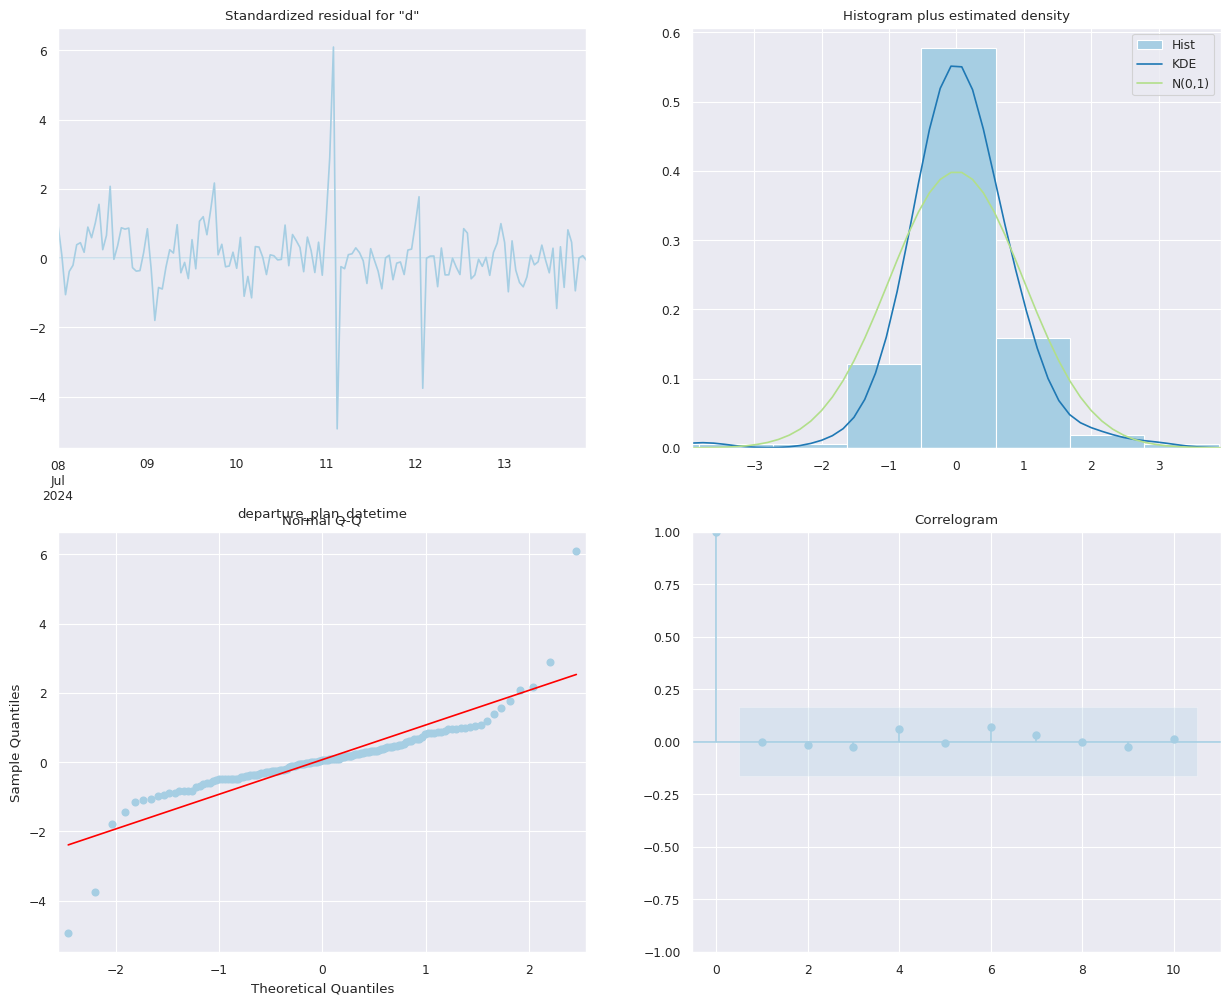

In [ ]:
model_fit.plot_diagnostics(figsize=(15, 12))
plt.show()

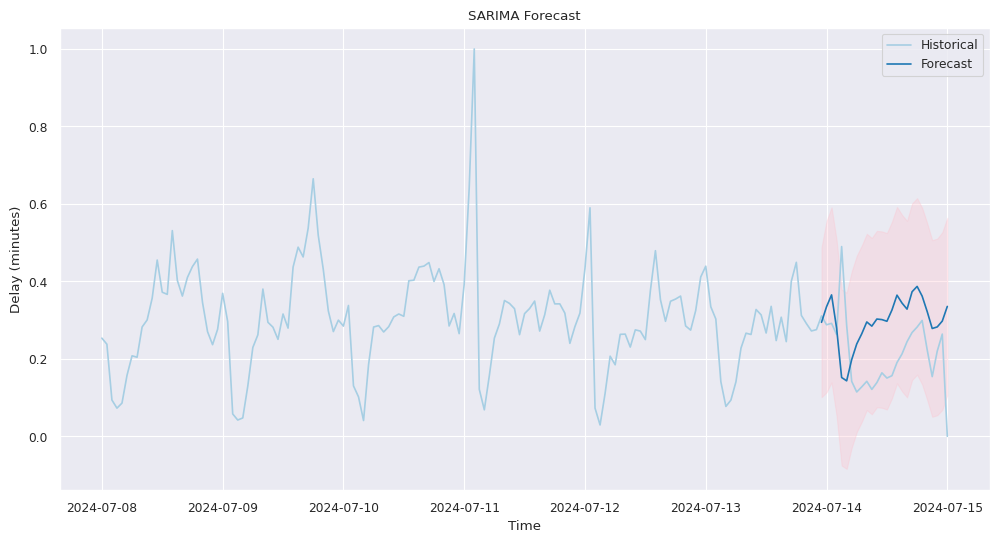

In [ ]:
forecast_steps = len(tsa_test)
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=tsa_test.index[0], periods=forecast_steps, freq='h')[0:]
forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)
confidence_intervals = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(tsa['departure_delay_m'], label='Historical')
plt.plot(forecast_series, label='Forecast')
plt.fill_between(forecast_index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast')
plt.xlabel('Time')
plt.ylabel('Delay (minutes)')
plt.legend()
plt.show()

In [ ]:
frames_train = {}
frames_test = {}
frames_forecast_l = {}
for state, data in frames.items():
    i_split = int(5/7 * len(data))
    frames_train[state], frames_test[state] = frames[state].iloc[:i_split,:], frames[state].iloc[i_split:,:]
    frames_forecast_l[state] = len(frames_test[state])

In [ ]:
models = {}
for state, data in frames_train.items():
    model = SARIMAX(data['departure_delay_m'],
                    order=best_params[:3],
                    seasonal_order=(3,0,3,24), #30224
                    )
    fit = model.fit(disp=False, maxiter=200)
    models[state] = fit
    print(f"fitted to {state}")

    if math.isinf(fit.zvalues.mean()):
        print(f'{state}not converged')

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


fitted to Niedersachsen


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


fitted to Baden-Württemberg


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


...

fitted to Saarland


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


fitted to Thüringen


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


fitted to Sachsen


calc for Niedersachsen


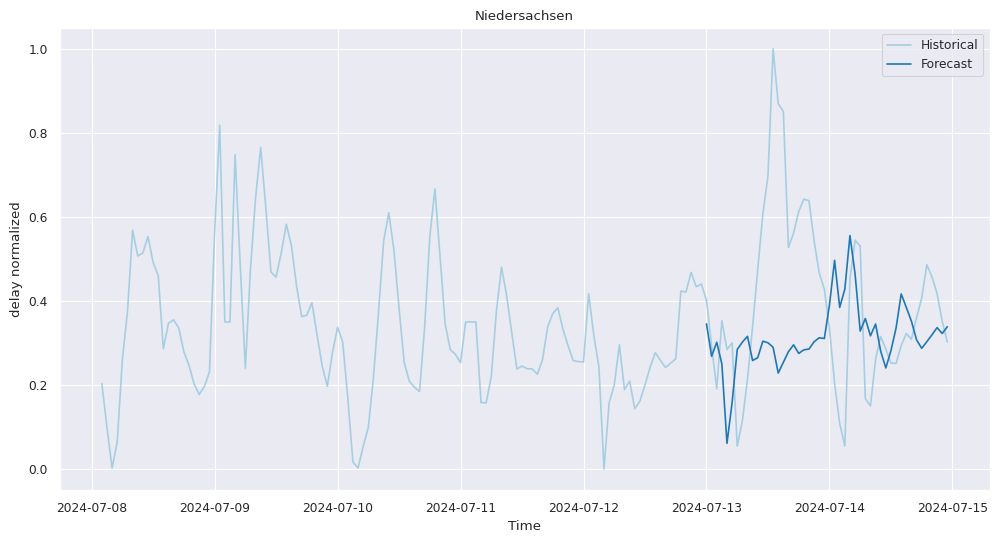

calc for Baden-Württemberg


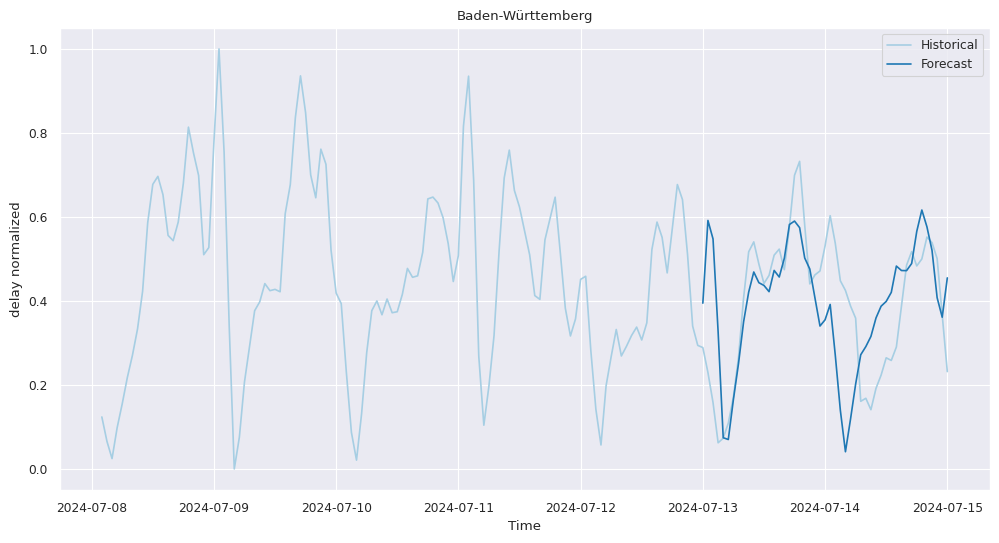

calc for Rheinland-Pfalz


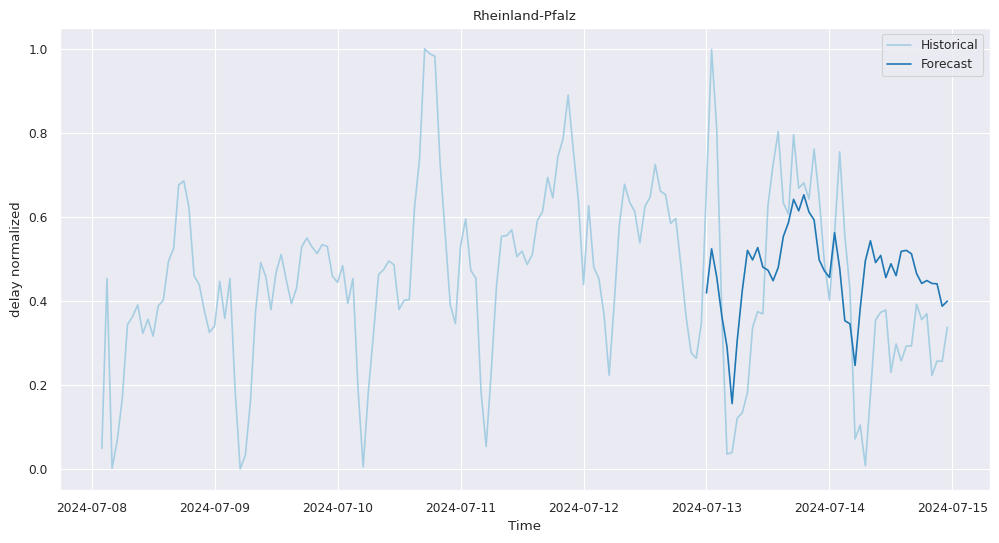

calc for Bayern


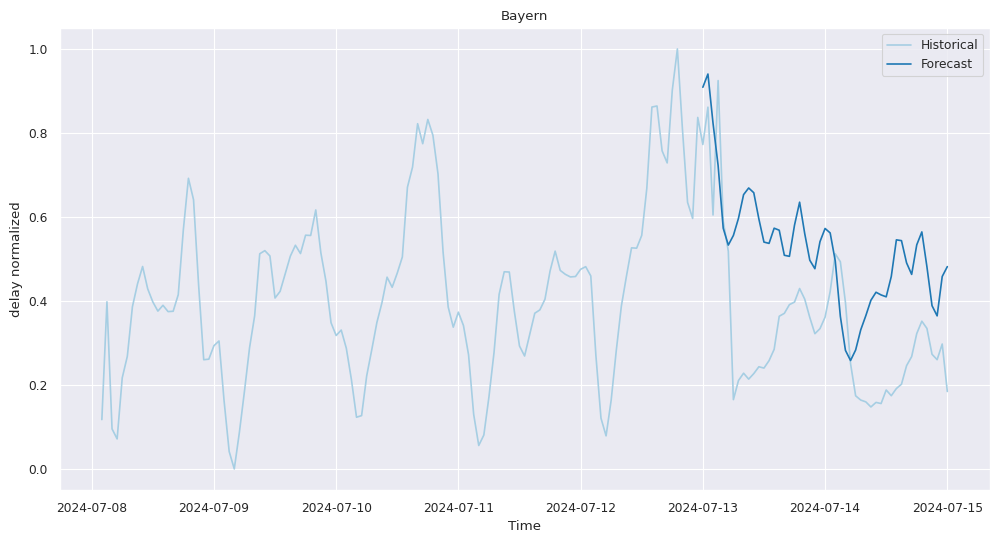

calc for Brandenburg


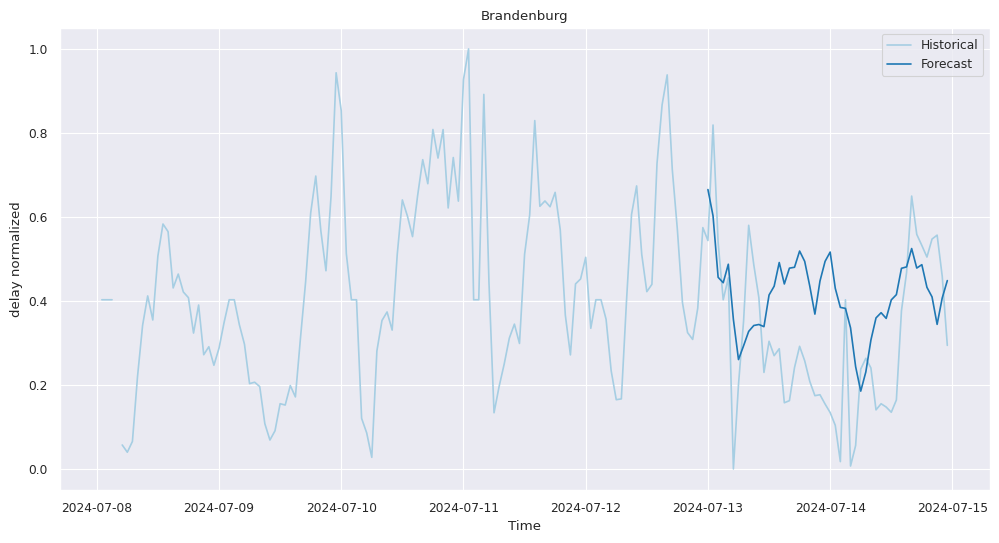

calc for Nordrhein-Westfalen


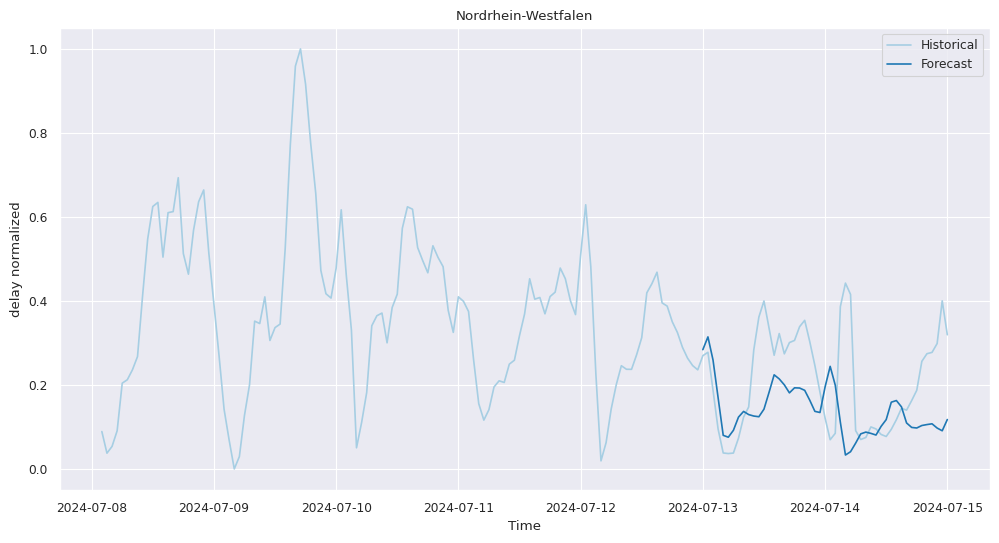

calc for Hamburg


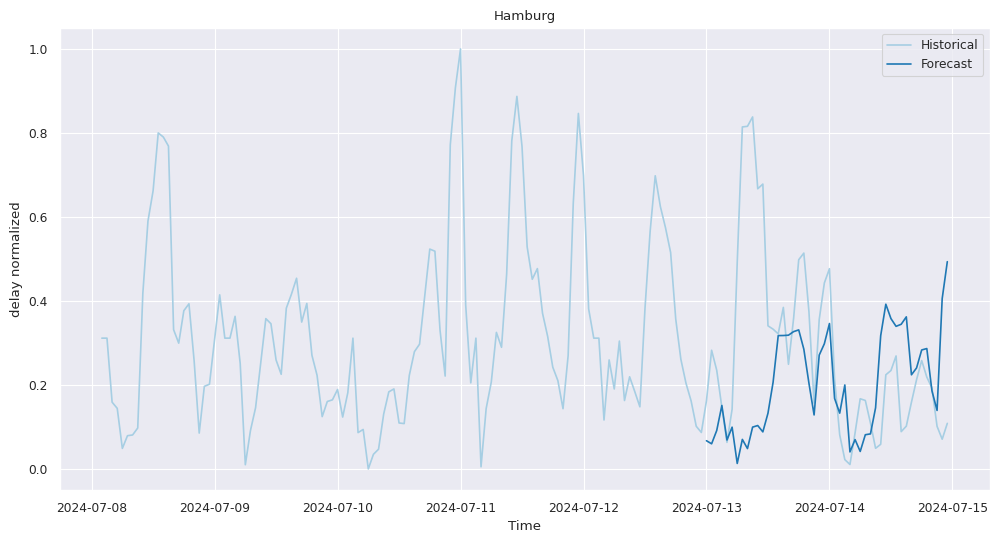

calc for Schleswig-Holstein


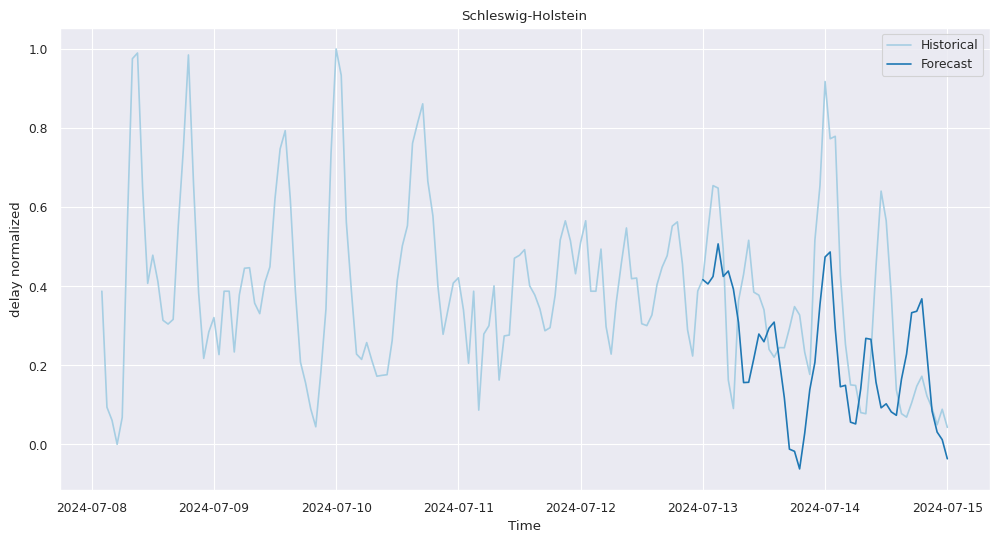

calc for Mecklenburg-Vorpommern


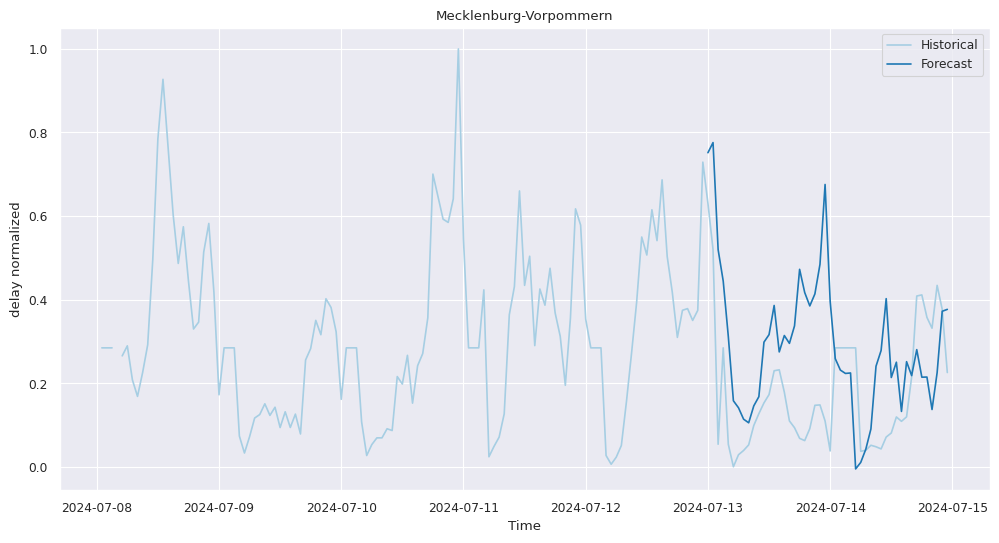

calc for Sachsen-Anhalt


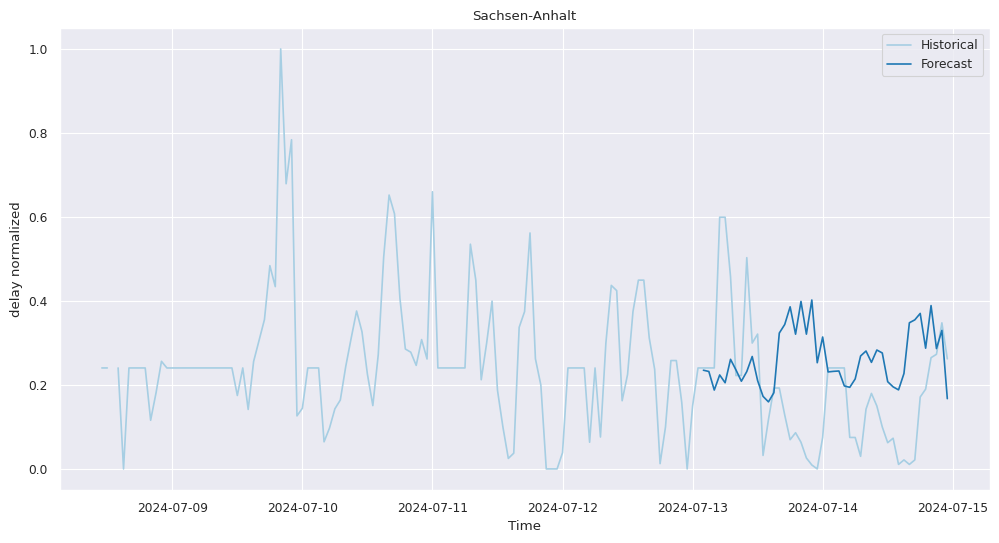

calc for Berlin


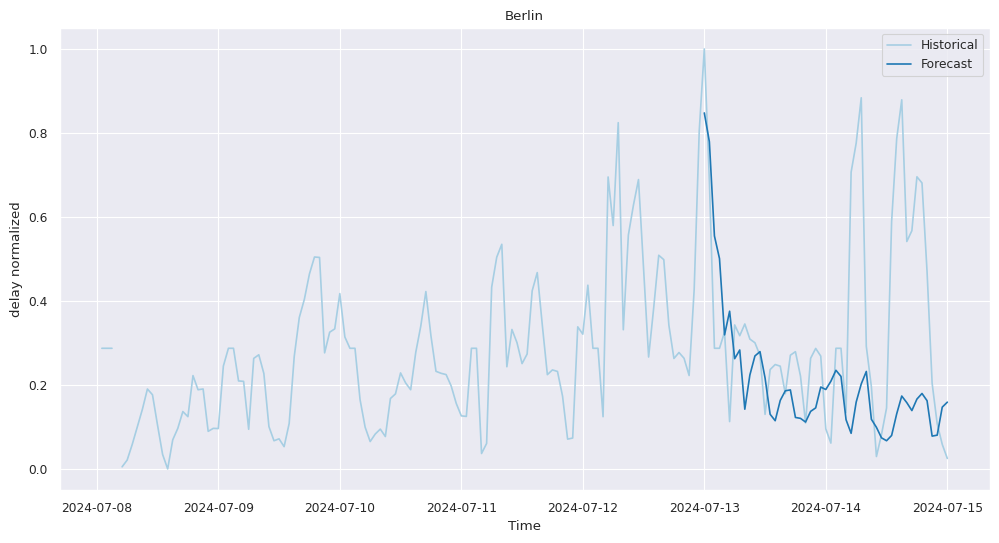

calc for Bremen


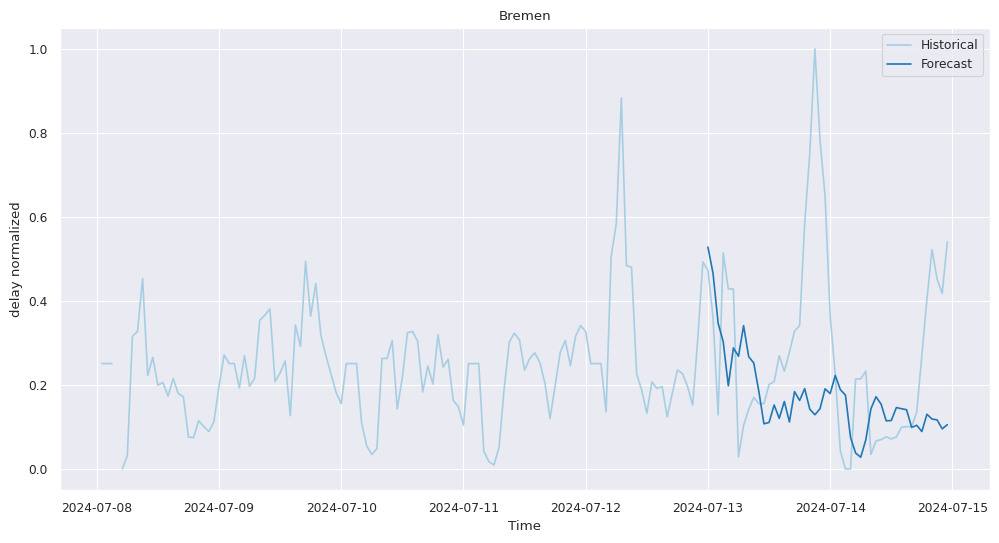

calc for Hessen


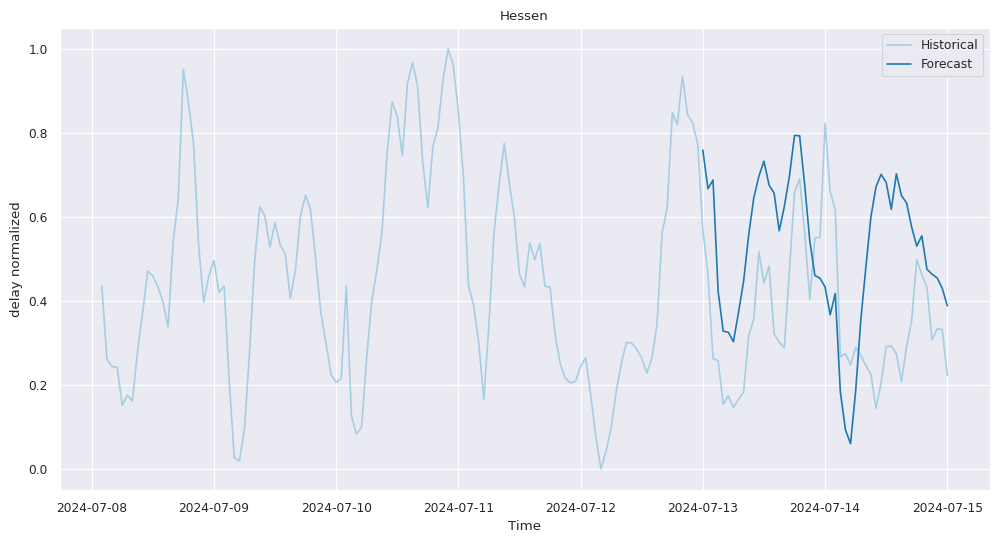

calc for Saarland


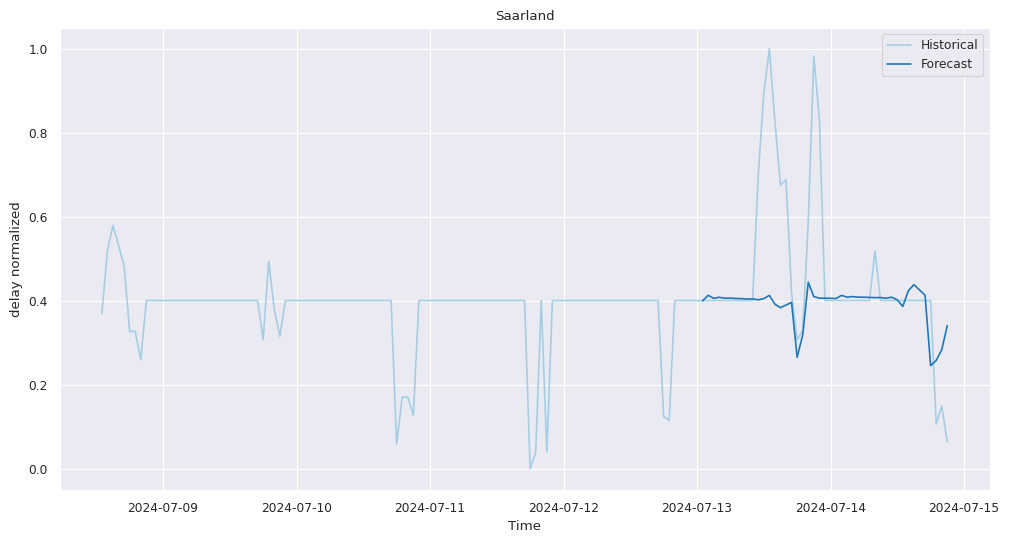

calc for Thüringen


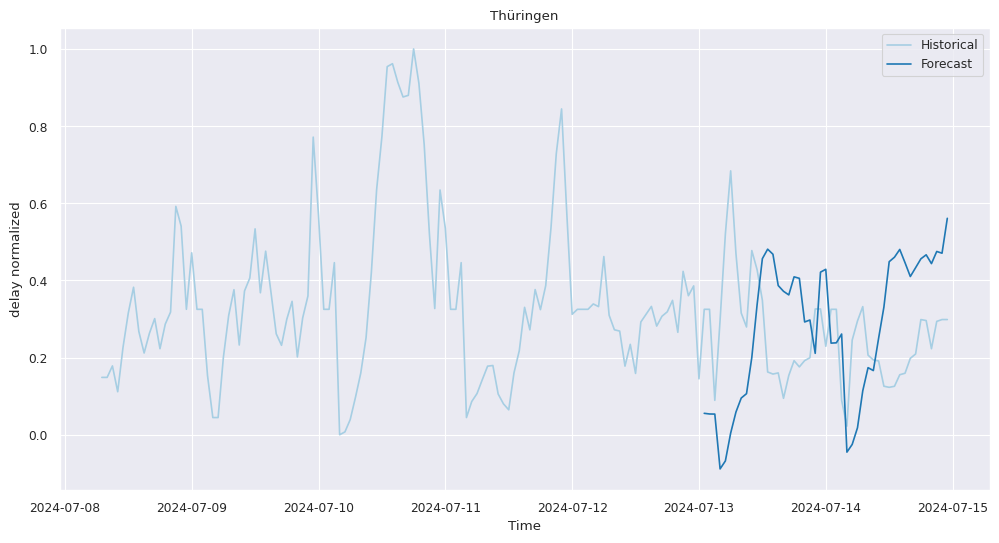

calc for Sachsen


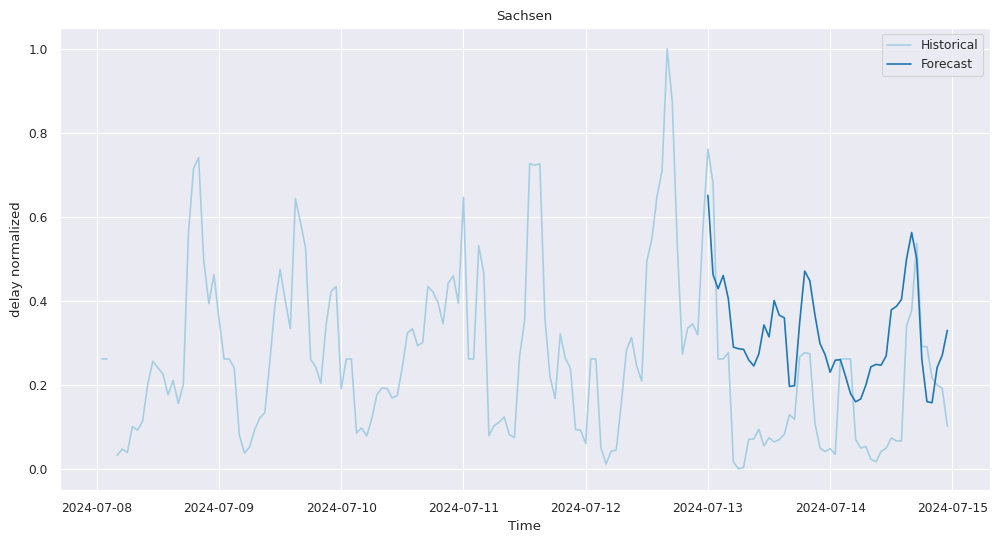

In [ ]:
forecasts = {}
comparison = pd.DataFrame(columns=["rmse", "std"])

for state, data in frames_test.items():
    try:
        forecast_steps = frames_forecast_l[state]
        forecast = models[state].get_forecast(steps=forecast_steps)
        forecast_index = pd.date_range(start=data.index[0], periods=forecast_steps, freq='h')
        forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)
        #confidence_intervals = forecast.conf_int()
        print(f"calc for {state}")
        rmse = np.sqrt(mean_squared_error(data["departure_delay_m"], forecast_series))
        comparison.loc[state, "rmse"] = rmse
        comparison.loc[state, "std"] = frames_test[state].departure_delay_m.std()



        # Plot the forecast
        plt.figure(figsize=(12, 6))
        plt.plot(frames[state]['departure_delay_m'], label='Historical')
        plt.plot(forecast_series, label='Forecast')
        plt.title(state)
        plt.xlabel('Time')
        plt.ylabel('delay normalized')
        plt.legend()
        plt.show()
    except:
        print(f"{state} is unpredictable")
        comparison.loc[state, "rmse"] = 1
        continue

## **Export models**

In [ ]:
import pickle

model_dir = '/content/models'

for state, model in models.items():
    with open(f'{model_dir}/{state}_sarimax_model.pkl', 'wb') as file:
        pickle.dump(model, file)

In [ ]:
!zip -r /content/models.zip /content/models

  adding: content/models/ (stored 0%)
  adding: content/models/Brandenburg_sarimax_model.pkl (deflated 53%)
  adding: content/models/Berlin_sarimax_model.pkl (deflated 52%)
  adding: content/models/Bayern_sarimax_model.pkl (deflated 54%)
  adding: content/models/Schleswig-Holstein_sarimax_model.pkl (deflated 53%)
  adding: content/models/Bremen_sarimax_model.pkl (deflated 52%)
  adding: content/models/Mecklenburg-Vorpommern_sarimax_model.pkl (deflated 51%)
  adding: content/models/Sachsen-Anhalt_sarimax_model.pkl (deflated 51%)
  adding: content/models/Nordrhein-Westfalen_sarimax_model.pkl (deflated 53%)
  adding: content/models/Thüringen_sarimax_model.pkl (deflated 53%)
  adding: content/models/Saarland_sarimax_model.pkl (deflated 54%)
  adding: content/models/Hamburg_sarimax_model.pkl (deflated 54%)
  adding: content/models/Hessen_sarimax_model.pkl (deflated 54%)
  adding: content/models/Rheinland-Pfalz_sarimax_model.pkl (deflated 51%)
  adding: content/models/Sachsen_sarimax_model.p

In [ ]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)